## Разделение данных на train и test


In [ ]:
# Границы дат
train_start = pd.to_datetime('2020-01-01')
train_end = pd.to_datetime('2024-11-30')

# Тестовые периоды (раздельно!)
test_dec_start = pd.to_datetime('2024-12-01')
test_dec_end = pd.to_datetime('2024-12-31')

test_jan_start = pd.to_datetime('2025-01-01')
test_jan_end = pd.to_datetime('2025-01-31')

# Валидация
val_start = pd.to_datetime('2025-02-01')
val_end = pd.to_datetime('2025-02-28')

# Разделение данных
train_data = data_encoded[(data['researchDate'] >= train_start) &
                          (data['researchDate'] <= train_end)]

test_dec = data_encoded[(data['researchDate'] >= test_dec_start) &
                        (data['researchDate'] <= test_dec_end)]

test_jan = data_encoded[(data['researchDate'] >= test_jan_start) &
                        (data['researchDate'] <= test_jan_end)]

val_data = data_encoded[(data['researchDate'] >= val_start) &
                        (data['researchDate'] <= val_end)]

In [ ]:
val_data['researchDate'] = val_data['researchDate'].astype(str)
train_data['researchDate'] = train_data['researchDate'].astype(str)

In [ ]:
train_data = train_data.dropna(subset=['lag_1'])
train_data = train_data.dropna(subset=['lag_5'])
train_data = train_data.dropna(subset=['rolling_mean_5'])
train_data = train_data.dropna(subset=['rolling_mean_10'])

In [ ]:
# Проверка
print(f"Train: {len(train_data)} записей ({train_start.date()} – {train_end.date()})")
print(f"Test (Декабрь 2024): {len(test_dec)} записей ({test_dec_start.date()} – {test_dec_end.date()})")
print(f"Test (Январь 2025): {len(test_jan)} записей ({test_jan_start.date()} – {test_jan_end.date()})")
print(f"Validation: {len(val_data)} записей ({val_start.date()} – {val_end.date()})")

Train: 1454407 записей (2020-01-01 – 2024-11-30)
Test (Декабрь 2024): 25712 записей (2024-12-01 – 2024-12-31)
Test (Январь 2025): 25103 записей (2025-01-01 – 2025-01-31)
Validation: 22870 записей (2025-02-01 – 2025-02-28)


In [ ]:
# Сохранение
train_data.to_csv('train.csv', index=False)
test_dec.to_csv('test_dec_2024.csv', index=False)
test_jan.to_csv('test_jan_2025.csv', index=False)
val_data.to_csv('validation.csv', index=False)

In [ ]:
train_data.head()

,researchDate,researchDayType,tvCompanyId,breaksSpotId,breaksDuration,breaksPrimeTimeStatusName,programFirstIssueDate,programAgeRestrictionName,programDuration,SalesRtgPer,predictions,hour,minute,second,day,month,year,tvCompanyName_Звезда,tvCompanyName_Мир,tvCompanyName_НТВ,tvCompanyName_Первый,tvCompanyName_РЕН ТВ,tvCompanyName_Россия 1,tvCompanyName_Россия 24,tvCompanyName_СТС,tvCompanyName_ТВ Центр,tvCompanyName_ТВ3,tvCompanyName_ТНТ,tvCompanyName_ТНТ4,tvCompanyName_Че,programTypeName_Детская программа,programTypeName_Документальная программа,programTypeName_Кинофильм,programTypeName_Музыкальная программа,programTypeName_Новости,programTypeName_Познавательная программа,programTypeName_Прочее,programTypeName_Развлекательная программа,programTypeName_Социально-политическая программа,programTypeName_Спортивная программа,programTypeName_Телесериал,programCategoryName_Детская передача,programCategoryName_Дневник спортивных событий,programCategoryName_Документальный сериал,programCategoryName_Документальный фильм,programCategoryName_Другая информационная передача,programCategoryName_Другая музыкально-танцевальная передача,programCategoryName_Другая познавательная передача,programCategoryName_Другая развлекательная передача,programCategoryName_Другая социально-политическая передача,...,programCategoryName_Мультипликационный фильм,programCategoryName_Народная музыка и танцы,programCategoryName_Научно-популярная передача,programCategoryName_Новости культуры,"programCategoryName_Передача о животных, растениях",programCategoryName_Передача о здоровье,programCategoryName_Передача о моде и дизайне,programCategoryName_Передача о спорте и спортсменах,programCategoryName_Передача об автомобилях,"programCategoryName_Передача об искусстве, культуре, истории",programCategoryName_Передача-диалог в прямом эфире,programCategoryName_Передача-интервью,programCategoryName_Поздравление,programCategoryName_Политическая передача,programCategoryName_Прогноз погоды,programCategoryName_Развлекательное ток-шоу,programCategoryName_Реалити-шоу,programCategoryName_Религиозная передача,"programCategoryName_Репортаж, трансляция","programCategoryName_Смешанный концерт, шоу, цирк",programCategoryName_Советы потребителю и реклама,"programCategoryName_Современная музыка, эстрадный концерт",programCategoryName_Социально-политическое ток-шоу,programCategoryName_Социально-публицистическая передача,"programCategoryName_Спектакль, литературное чтение",programCategoryName_Спортивные новости,programCategoryName_Спортивный журнал и аналитика,programCategoryName_Стиль жизни и досуг,programCategoryName_Телемагазин,programCategoryName_Телесериал,programCategoryName_Трансляция спортивного мероприятия,programCategoryName_Утренний эфир,programCategoryName_Хроники (кроме криминальных),programCategoryName_Экономика и бизнес,programCategoryName_Юмористическая передача,programName_freq,breaksStartTime_min,breaksFinishTime_min,programStartTime_min,programFinishTime_min,day_of_week,season,lag_1,lag_5,rolling_mean_5,rolling_mean_10,SalesRtgPer_log,log1p,yeojohnson,quantile
9,2020-01-01,2,1877,3676229463,190,1,1999-02-14 00:00:00,2,7426,0.437799,0.0,8,30,19,1,1,2020,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0.00005,510.316667,513.483333,470.1,593.866667,2,1,0.318004,0.764849,0.248016,0.681106,0.363113,0.363113,-0.183905,-0.139041
10,2020-01-01,2,1877,3676229473,190,1,1999-02-14 00:00:00,2,7426,0.464611,0.0,8,41,52,1,1,2020,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,Fal

In [ ]:
test_dec.head()

,researchDate,researchDayType,tvCompanyId,breaksSpotId,breaksDuration,breaksPrimeTimeStatusName,programFirstIssueDate,programAgeRestrictionName,programDuration,SalesRtgPer,predictions,hour,minute,second,day,month,year,tvCompanyName_Звезда,tvCompanyName_Мир,tvCompanyName_НТВ,tvCompanyName_Первый,tvCompanyName_РЕН ТВ,tvCompanyName_Россия 1,tvCompanyName_Россия 24,tvCompanyName_СТС,tvCompanyName_ТВ Центр,tvCompanyName_ТВ3,tvCompanyName_ТНТ,tvCompanyName_ТНТ4,tvCompanyName_Че,programTypeName_Детская программа,programTypeName_Документальная программа,programTypeName_Кинофильм,programTypeName_Музыкальная программа,programTypeName_Новости,programTypeName_Познавательная программа,programTypeName_Прочее,programTypeName_Развлекательная программа,programTypeName_Социально-политическая программа,programTypeName_Спортивная программа,programTypeName_Телесериал,programCategoryName_Детская передача,programCategoryName_Дневник спортивных событий,programCategoryName_Документальный сериал,programCategoryName_Документальный фильм,programCategoryName_Другая информационная передача,programCategoryName_Другая музыкально-танцевальная передача,programCategoryName_Другая познавательная передача,programCategoryName_Другая развлекательная передача,programCategoryName_Другая социально-политическая передача,...,programCategoryName_Мультипликационный фильм,programCategoryName_Народная музыка и танцы,programCategoryName_Научно-популярная передача,programCategoryName_Новости культуры,"programCategoryName_Передача о животных, растениях",programCategoryName_Передача о здоровье,programCategoryName_Передача о моде и дизайне,programCategoryName_Передача о спорте и спортсменах,programCategoryName_Передача об автомобилях,"programCategoryName_Передача об искусстве, культуре, истории",programCategoryName_Передача-диалог в прямом эфире,programCategoryName_Передача-интервью,programCategoryName_Поздравление,programCategoryName_Политическая передача,programCategoryName_Прогноз погоды,programCategoryName_Развлекательное ток-шоу,programCategoryName_Реалити-шоу,programCategoryName_Религиозная передача,"programCategoryName_Репортаж, трансляция","programCategoryName_Смешанный концерт, шоу, цирк",programCategoryName_Советы потребителю и реклама,"programCategoryName_Современная музыка, эстрадный концерт",programCategoryName_Социально-политическое ток-шоу,programCategoryName_Социально-публицистическая передача,"programCategoryName_Спектакль, литературное чтение",programCategoryName_Спортивные новости,programCategoryName_Спортивный журнал и аналитика,programCategoryName_Стиль жизни и досуг,programCategoryName_Телемагазин,programCategoryName_Телесериал,programCategoryName_Трансляция спортивного мероприятия,programCategoryName_Утренний эфир,programCategoryName_Хроники (кроме криминальных),programCategoryName_Экономика и бизнес,programCategoryName_Юмористическая передача,programName_freq,breaksStartTime_min,breaksFinishTime_min,programStartTime_min,programFinishTime_min,day_of_week,season,lag_1,lag_5,rolling_mean_5,rolling_mean_10,SalesRtgPer_log,log1p,yeojohnson,quantile
1454418,2024-12-01,1,1877,6040971517,203,0,2014-04-14,3,3200,1.1305,0.0,0,8,53,1,12,2024,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,0.001268,8.883333,12.266667,2.900000,56.233333,6,1,0.1710,0.1520,0.3496,0.26125,0.756357,0.756357,0.933115,0.832135
1454419,2024-12-01,1,1877,6040971533,205,0,2014-04-14,3,3200,1.0545,0.0,0,24,44,1,12,2024,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False

In [ ]:
test_jan.head()

,researchDate,researchDayType,tvCompanyId,breaksSpotId,breaksDuration,breaksPrimeTimeStatusName,programFirstIssueDate,programAgeRestrictionName,programDuration,SalesRtgPer,predictions,hour,minute,second,day,month,year,tvCompanyName_Звезда,tvCompanyName_Мир,tvCompanyName_НТВ,tvCompanyName_Первый,tvCompanyName_РЕН ТВ,tvCompanyName_Россия 1,tvCompanyName_Россия 24,tvCompanyName_СТС,tvCompanyName_ТВ Центр,tvCompanyName_ТВ3,tvCompanyName_ТНТ,tvCompanyName_ТНТ4,tvCompanyName_Че,programTypeName_Детская программа,programTypeName_Документальная программа,programTypeName_Кинофильм,programTypeName_Музыкальная программа,programTypeName_Новости,programTypeName_Познавательная программа,programTypeName_Прочее,programTypeName_Развлекательная программа,programTypeName_Социально-политическая программа,programTypeName_Спортивная программа,programTypeName_Телесериал,programCategoryName_Детская передача,programCategoryName_Дневник спортивных событий,programCategoryName_Документальный сериал,programCategoryName_Документальный фильм,programCategoryName_Другая информационная передача,programCategoryName_Другая музыкально-танцевальная передача,programCategoryName_Другая познавательная передача,programCategoryName_Другая развлекательная передача,programCategoryName_Другая социально-политическая передача,...,programCategoryName_Мультипликационный фильм,programCategoryName_Народная музыка и танцы,programCategoryName_Научно-популярная передача,programCategoryName_Новости культуры,"programCategoryName_Передача о животных, растениях",programCategoryName_Передача о здоровье,programCategoryName_Передача о моде и дизайне,programCategoryName_Передача о спорте и спортсменах,programCategoryName_Передача об автомобилях,"programCategoryName_Передача об искусстве, культуре, истории",programCategoryName_Передача-диалог в прямом эфире,programCategoryName_Передача-интервью,programCategoryName_Поздравление,programCategoryName_Политическая передача,programCategoryName_Прогноз погоды,programCategoryName_Развлекательное ток-шоу,programCategoryName_Реалити-шоу,programCategoryName_Религиозная передача,"programCategoryName_Репортаж, трансляция","programCategoryName_Смешанный концерт, шоу, цирк",programCategoryName_Советы потребителю и реклама,"programCategoryName_Современная музыка, эстрадный концерт",programCategoryName_Социально-политическое ток-шоу,programCategoryName_Социально-публицистическая передача,"programCategoryName_Спектакль, литературное чтение",programCategoryName_Спортивные новости,programCategoryName_Спортивный журнал и аналитика,programCategoryName_Стиль жизни и досуг,programCategoryName_Телемагазин,programCategoryName_Телесериал,programCategoryName_Трансляция спортивного мероприятия,programCategoryName_Утренний эфир,programCategoryName_Хроники (кроме криминальных),programCategoryName_Экономика и бизнес,programCategoryName_Юмористическая передача,programName_freq,breaksStartTime_min,breaksFinishTime_min,programStartTime_min,programFinishTime_min,day_of_week,season,lag_1,lag_5,rolling_mean_5,rolling_mean_10,SalesRtgPer_log,log1p,yeojohnson,quantile
1480130,2025-01-01,2,1877,6096018812,175,0,39328,3,2344,0.950,0.0,0,12,26,1,1,2025,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,0.017435,12.433333,15.350000,1423.166667,22.233333,2,1,0.019,0.1330,0.2242,0.16340,0.667829,0.667829,0.724126,0.658043
1480131,2025-01-01,2,1877,6096018835,178,0,39328,3,2719,0.855,0.0,0,30,3,1,1,2025,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,Fals

In [ ]:
val_data.head()

,researchDate,researchDayType,tvCompanyId,breaksSpotId,breaksDuration,breaksPrimeTimeStatusName,programFirstIssueDate,programAgeRestrictionName,programDuration,SalesRtgPer,predictions,hour,minute,second,day,month,year,tvCompanyName_Звезда,tvCompanyName_Мир,tvCompanyName_НТВ,tvCompanyName_Первый,tvCompanyName_РЕН ТВ,tvCompanyName_Россия 1,tvCompanyName_Россия 24,tvCompanyName_СТС,tvCompanyName_ТВ Центр,tvCompanyName_ТВ3,tvCompanyName_ТНТ,tvCompanyName_ТНТ4,tvCompanyName_Че,programTypeName_Детская программа,programTypeName_Документальная программа,programTypeName_Кинофильм,programTypeName_Музыкальная программа,programTypeName_Новости,programTypeName_Познавательная программа,programTypeName_Прочее,programTypeName_Развлекательная программа,programTypeName_Социально-политическая программа,programTypeName_Спортивная программа,programTypeName_Телесериал,programCategoryName_Детская передача,programCategoryName_Дневник спортивных событий,programCategoryName_Документальный сериал,programCategoryName_Документальный фильм,programCategoryName_Другая информационная передача,programCategoryName_Другая музыкально-танцевальная передача,programCategoryName_Другая познавательная передача,programCategoryName_Другая развлекательная передача,programCategoryName_Другая социально-политическая передача,...,programCategoryName_Мультипликационный фильм,programCategoryName_Народная музыка и танцы,programCategoryName_Научно-популярная передача,programCategoryName_Новости культуры,"programCategoryName_Передача о животных, растениях",programCategoryName_Передача о здоровье,programCategoryName_Передача о моде и дизайне,programCategoryName_Передача о спорте и спортсменах,programCategoryName_Передача об автомобилях,"programCategoryName_Передача об искусстве, культуре, истории",programCategoryName_Передача-диалог в прямом эфире,programCategoryName_Передача-интервью,programCategoryName_Поздравление,programCategoryName_Политическая передача,programCategoryName_Прогноз погоды,programCategoryName_Развлекательное ток-шоу,programCategoryName_Реалити-шоу,programCategoryName_Религиозная передача,"programCategoryName_Репортаж, трансляция","programCategoryName_Смешанный концерт, шоу, цирк",programCategoryName_Советы потребителю и реклама,"programCategoryName_Современная музыка, эстрадный концерт",programCategoryName_Социально-политическое ток-шоу,programCategoryName_Социально-публицистическая передача,"programCategoryName_Спектакль, литературное чтение",programCategoryName_Спортивные новости,programCategoryName_Спортивный журнал и аналитика,programCategoryName_Стиль жизни и досуг,programCategoryName_Телемагазин,programCategoryName_Телесериал,programCategoryName_Трансляция спортивного мероприятия,programCategoryName_Утренний эфир,programCategoryName_Хроники (кроме криминальных),programCategoryName_Экономика и бизнес,programCategoryName_Юмористическая передача,programName_freq,breaksStartTime_min,breaksFinishTime_min,programStartTime_min,programFinishTime_min,day_of_week,season,lag_1,lag_5,rolling_mean_5,rolling_mean_10,SalesRtgPer_log,log1p,yeojohnson,quantile
1505233,2025-02-01,1,1875,6147205144,190,0,2010-12-18 00:00:00,1,4951,0.818327,0.0,6,20,9,1,2,2025,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0.000012,380.150000,383.316667,344.633333,427.150000,5,1,0.095000,0.095,0.239665,0.186333,0.597917,0.597917,0.54322,0.490721
1505234,2025-02-01,1,1875,6147205158,188,0,2010-12-18 00:00:00,1,4951,0.818327,0.0,6,33,15,1,2,2025,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False

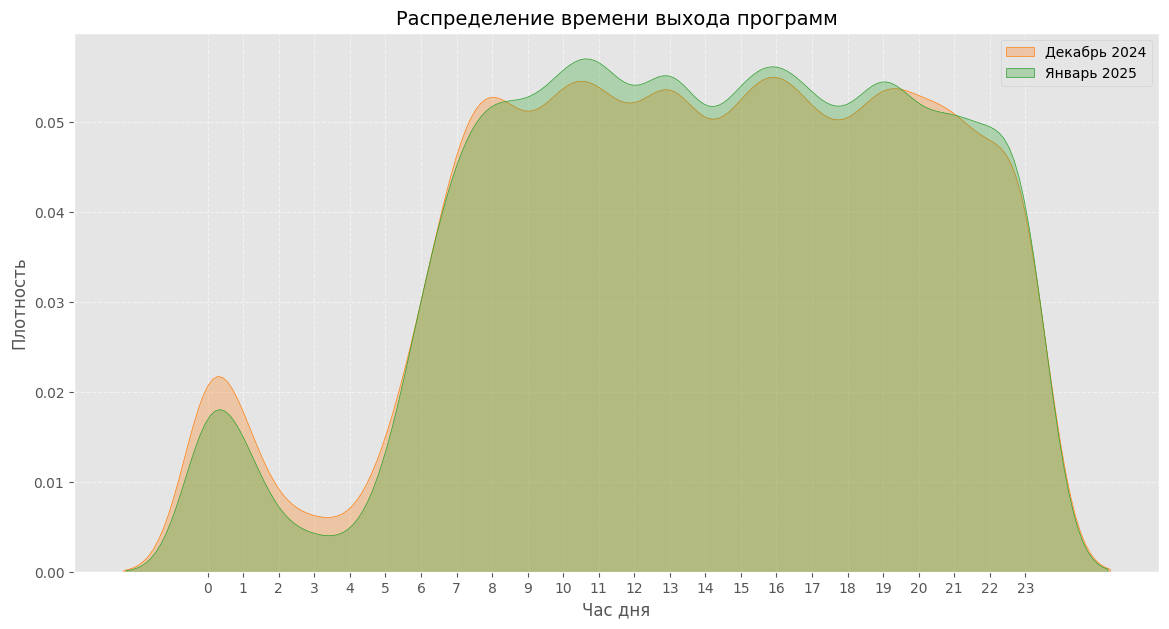

In [ ]:
plt.figure(figsize=(14, 7))

# Преобразуем время в часы
data['hour'] = pd.to_datetime(data['programStartTime']).dt.hour

# Фильтруем данные
dec_data = data[(data['researchDate'].dt.month == 12) & (data['researchDate'].dt.year == 2024)]
jan_data = data[(data['researchDate'].dt.month == 1) & (data['researchDate'].dt.year == 2025)]

# Визуализация
sns.kdeplot(data=dec_data, x='hour', label='Декабрь 2024',
           color='#FF7F0E', fill=True, alpha=0.3)
sns.kdeplot(data=jan_data, x='hour', label='Январь 2025',
           color='#2CA02C', fill=True, alpha=0.3)

plt.title('Распределение времени выхода программ', fontsize=14)
plt.xlabel('Час дня')
plt.ylabel('Плотность')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Признаки и целевая переменная

In [ ]:
features = [

    # Порядковые и бинарные
    'researchDayType',
    'programAgeRestrictionName',
    'breaksPrimeTimeStatusName',

    # Числовые
    'breaksDuration',
    'programDuration',
    'tvCompanyId',
    'lag_1',
    'lag_5',
    'rolling_mean_5',
    'rolling_mean_10',

    # Временные
    'day_of_week',
    'month',
    'season'
]
target = 'SalesRtgPer_log'

X_train, y_train = train_data[features], train_data[target]
X_test, y_test = test_dec[features], test_dec[target]

Доработка по удалению нулей

In [ ]:
# Удаление строк с нулями в целевой переменной
data_encoded = data_encoded[data_encoded['SalesRtgPer_log'] != 0]

# Проверим, что нулей больше нет
print("Осталось нулей:", (data_encoded['SalesRtgPer_log'] == 0).sum())
print("Размер датафрейма после удаления:", data_encoded.shape)


Осталось нулей: 0
Размер датафрейма после удаления: (1521317, 111)


In [ ]:
X_train = X_train[y_train != 0]
y_train = y_train[y_train != 0]

X_test = X_test[y_test != 0]
y_test = y_test[y_test != 0]

# Проверка
print(f"Новая размерность X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Новая размерность X_test: {X_test.shape}, y_test: {y_test.shape}")
print(f"Количество нулей в y_train: {(y_train == 0).sum()}")
print(f"Количество нулей в y_test: {(y_test == 0).sum()}")

Новая размерность X_train: (1448774, 13), y_train: (1448774,)
Новая размерность X_test: (25616, 13), y_test: (25616,)
Количество нулей в y_train: 0
Количество нулей в y_test: 0
